In [20]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import warnings
data_dir = Path("cleaned_data")
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

yellow_taxi = spark.read.parquet(f"{data_dir / 'yellow_data.parquet'}")
fhvhv_taxi = spark.read.parquet(f"{data_dir / 'fhvhv_data.parquet'}")
warnings.filterwarnings("ignore", module="pyspark")
yellow_taxi.show(1)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|trip_duration|pickup_year|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------+-----------+
|       1| 2023-05-01 00:42:49|  2023-05-01 01:11:18

In [2]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")
geo_data.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


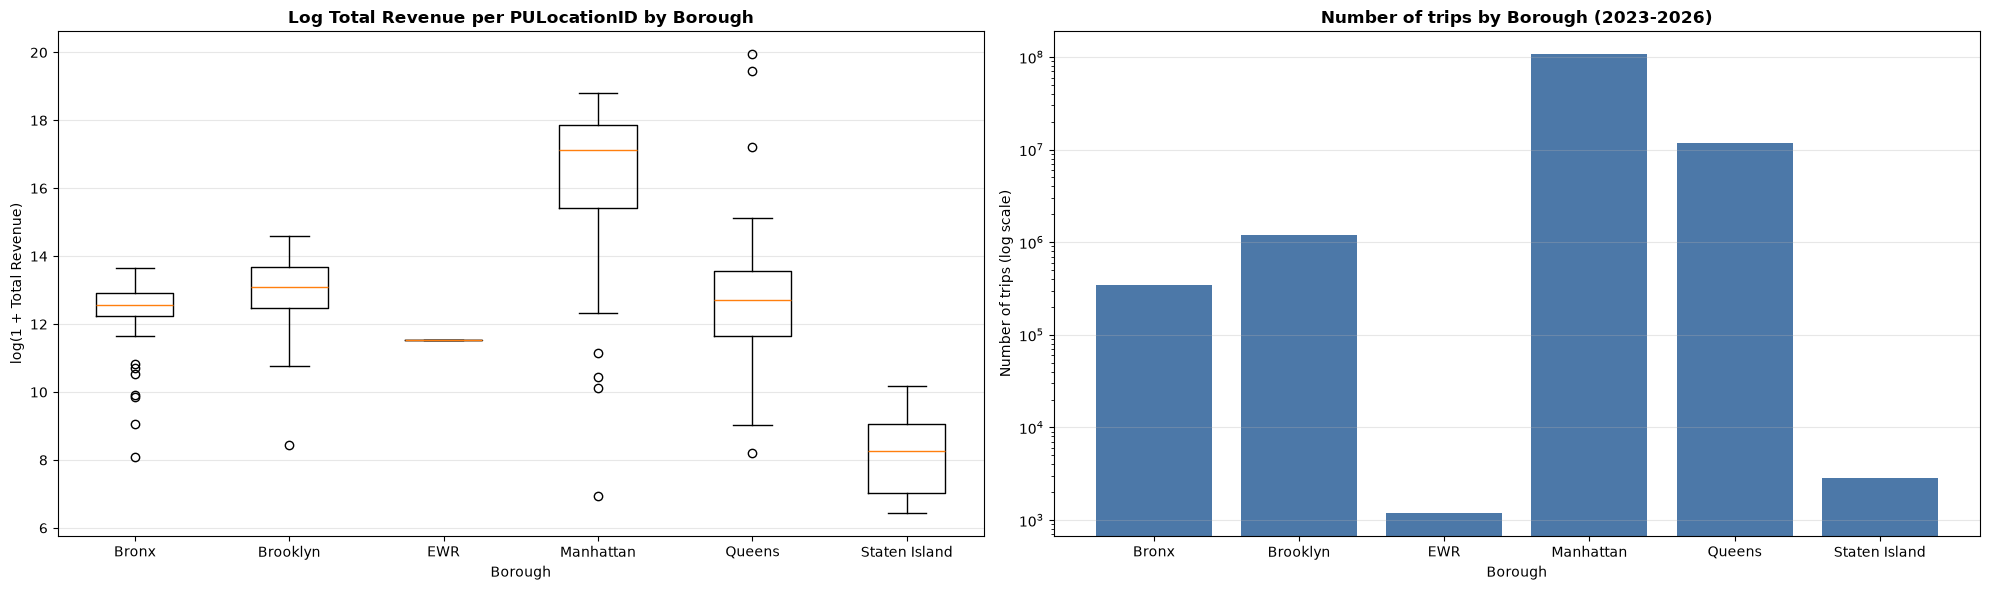

In [41]:
# --------------------------------------------------
# Step 1: Create Spark lookup table from geo_data
# --------------------------------------------------

borough_lookup_pd = (
    geo_data[["LocationID", "borough"]]
    .drop_duplicates()
)

borough_lookup_spark = spark.createDataFrame(borough_lookup_pd)


# --------------------------------------------------
# Step 2: Add Borough to yellow_taxi
# --------------------------------------------------

yellow_taxi_with_borough = (
    yellow_taxi
    .join(
        borough_lookup_spark,
        yellow_taxi["PULocationID"] == borough_lookup_spark["LocationID"],
        how="left"
    )
    .drop("LocationID")
    .withColumnRenamed("borough", "Borough")
)


# --------------------------------------------------
# Step 3: Total revenue for each PULocationID
# over the ENTIRE time period
# --------------------------------------------------

location_total_revenue = (
    yellow_taxi_with_borough
    .groupBy("PULocationID", "Borough")
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
    .withColumn(
        "log_total_revenue",
        F.log1p("total_revenue")
    )
)


# --------------------------------------------------
# Step 4: Count number of trips for each Borough
# --------------------------------------------------

borough_trip_counts = (
    yellow_taxi_with_borough
    .groupBy("Borough")
    .agg(
        F.count("*").alias("number_of_trips")
    )
    .orderBy("Borough")
)


# --------------------------------------------------
# Step 5: Convert both results to Pandas
# --------------------------------------------------

location_total_revenue_pd = location_total_revenue.toPandas()
borough_trip_counts_pd = borough_trip_counts.toPandas()


# --------------------------------------------------
# Step 6: Prepare boxplot data
# --------------------------------------------------

boroughs = sorted(
    location_total_revenue_pd["Borough"]
    .dropna()
    .unique()
)

boxplot_data = [
    location_total_revenue_pd.loc[
        location_total_revenue_pd["Borough"] == borough,
        "log_total_revenue"
    ].dropna()
    for borough in boroughs
]


# --------------------------------------------------
# Step 7: Create 1x2 subplot
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 6)
)


# ==================================================
# LEFT: Boxplot of log total revenue
# ==================================================

axes[0].boxplot(
    boxplot_data,
    tick_labels=boroughs
)

axes[0].set_title(
    "Log Total Revenue per PULocationID by Borough",
    fontweight="bold"
)

axes[0].set_xlabel("Borough")
axes[0].set_ylabel("log(1 + Total Revenue)")
axes[0].grid(axis="y", alpha=0.3)


# ==================================================
# RIGHT: Number of trips by Borough
# ==================================================

axes[1].bar(
    borough_trip_counts_pd["Borough"],
    borough_trip_counts_pd["number_of_trips"],
    color='#4C78A8'
)

axes[1].set_title(
    "Number of trips by Borough (2023-2026)",
    fontweight="bold"
)

axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Number of trips (log scale)")
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.3)


# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.tight_layout()
plt.show()

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


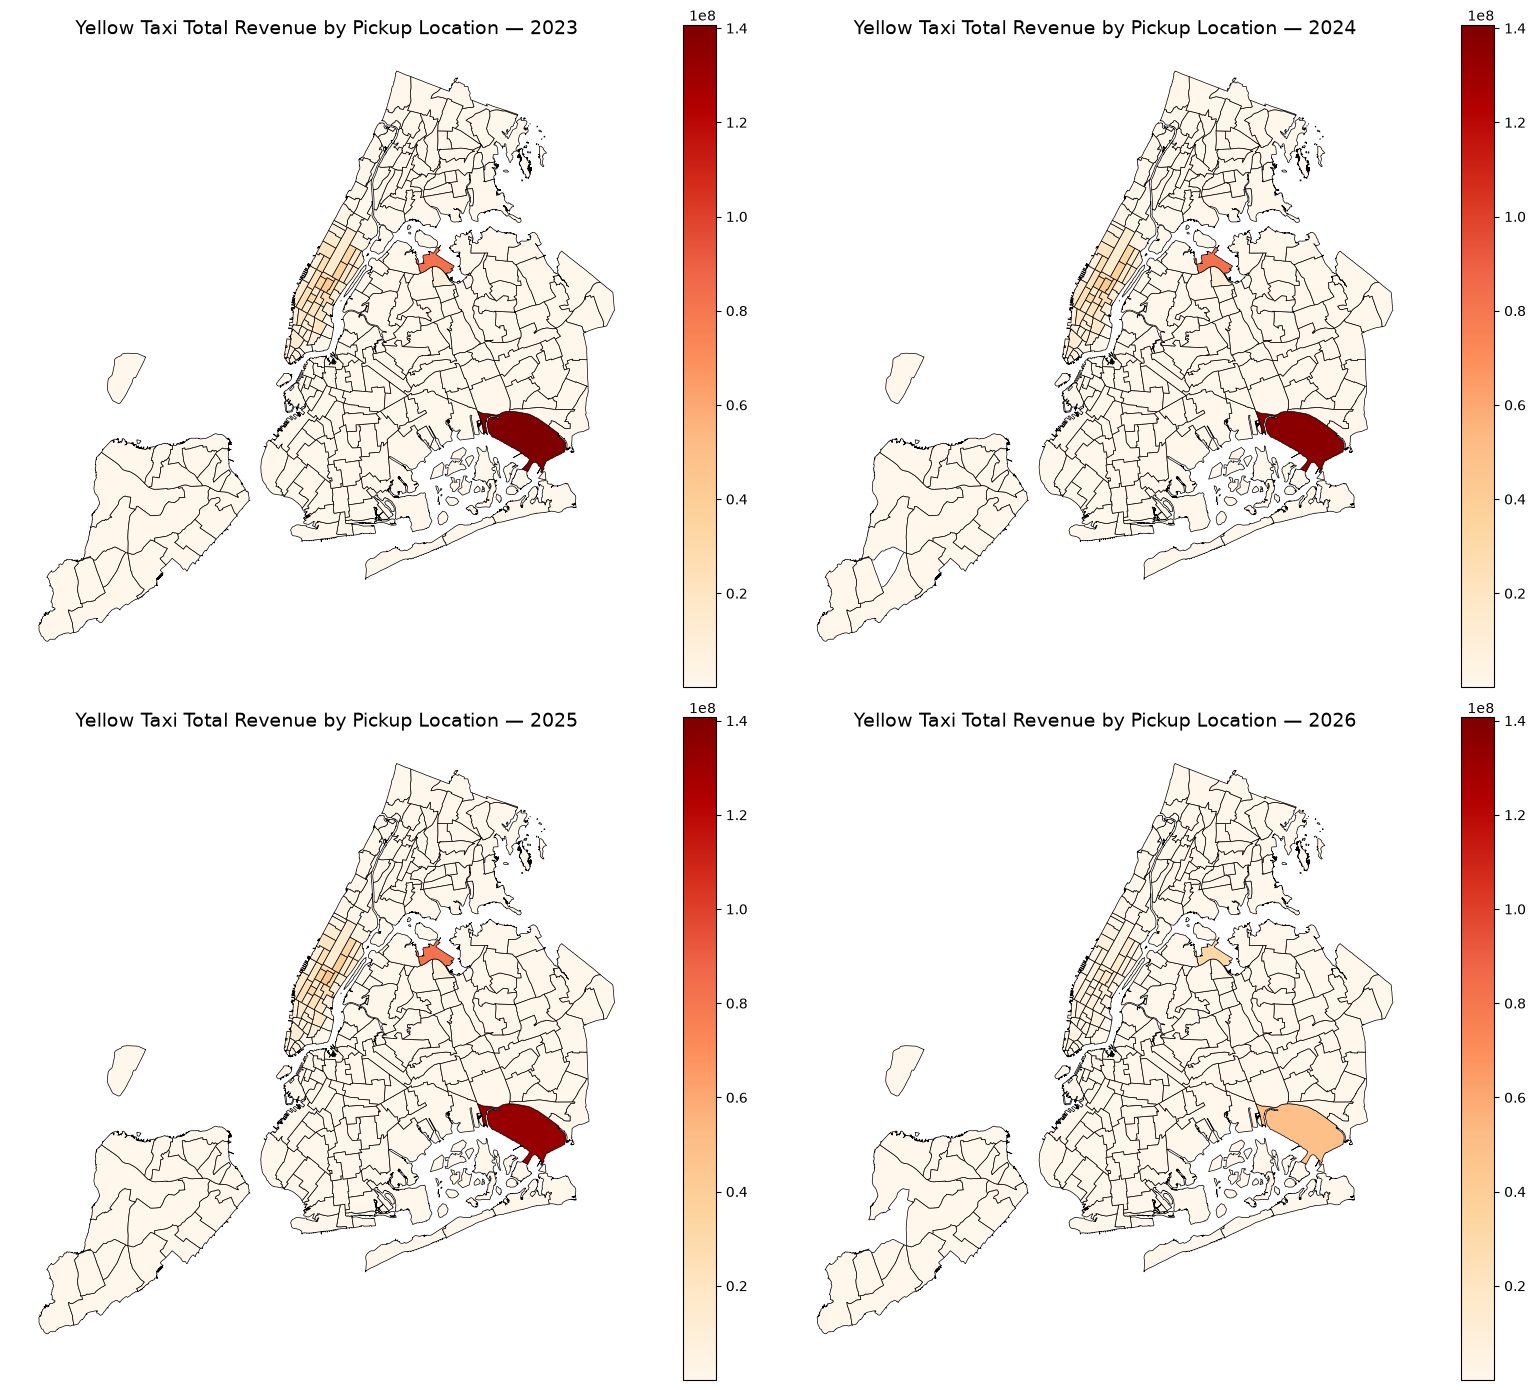

<Figure size 640x480 with 0 Axes>

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Aggregate yellow_taxi by year and pickup LocationID
# ---------------------------------------------------------

yellow_taxi_yearly = (
    yellow_taxi
    .withColumn(
        "year",
        F.year(F.col("tpep_pickup_datetime"))
    )
    .groupBy("year", "PULocationID")
    .agg(
        F.sum("total_amount").alias("total_amount")
    )
    .orderBy("year", "PULocationID")
)



# ---------------------------------------------------------
# 2. Convert the aggregated Spark DataFrame to Pandas
# ---------------------------------------------------------

yellow_taxi_yearly_pd = yellow_taxi_yearly.toPandas()


# ---------------------------------------------------------
# 3. Make sure LocationID types match before joining
# ---------------------------------------------------------

yellow_taxi_yearly_pd["PULocationID"] = (
    yellow_taxi_yearly_pd["PULocationID"].astype(int)
)

geo_data["LocationID"] = geo_data["LocationID"].astype(int)


# ---------------------------------------------------------
# 4. Join yearly totals onto the geographic polygons
# ---------------------------------------------------------

geo_yearly = geo_data.merge(
    yellow_taxi_yearly_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)


# ---------------------------------------------------------
# 5. Create four-panel choropleth
# ---------------------------------------------------------

years = [2023, 2024, 2025, 2026]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14)
)

axes = axes.flatten()

# Use the same color scale across all four years so that
# colors are directly comparable between years.
vmin = geo_yearly["total_amount"].min()
vmax = geo_yearly["total_amount"].max()

for ax, year in zip(axes, years):

    # Select the data for this year
    year_data = geo_yearly[
        geo_yearly["year"] == year
    ].copy()

    # Plot polygons
    year_data.plot(
        column="total_amount",
        ax=ax,
        cmap="OrRd",
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Yellow Taxi Total Revenue by Pickup Location — {year}",
        fontsize=14
    )

    ax.set_axis_off()


plt.tight_layout()
plt.show()
# save the plot as a PNG file in the path images
plt.savefig("images/yellow_taxi_revenue_by_location.png")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


def find_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


# ---------------------------------------------------------
# Find relevant columns
# ---------------------------------------------------------

fhv_pickup_col = 'pickup_datetime'
yellow_pickup_col = 'tpep_pickup_datetime'

fhv_money_col = 'driver_pay'

yellow_money_col = 'total_amount'

# ---------------------------------------------------------
# Aggregate FHV data in Spark
# ---------------------------------------------------------

fhv_daily = (
    fhvhv_taxi
    .filter(
        F.col(fhv_pickup_col).isNotNull() &
        F.col(fhv_money_col).isNotNull()
    )
    .groupBy(
        F.to_date(F.col(fhv_pickup_col)).alias("date")
    )
    .agg(
        F.sum(F.col(fhv_money_col)).alias("driver_pay")
    )
)


# ---------------------------------------------------------
# Aggregate Yellow Taxi data in Spark
# ---------------------------------------------------------

yellow_daily = (
    yellow_taxi
    .filter(
        F.col(yellow_pickup_col).isNotNull() &
        F.col(yellow_money_col).isNotNull()
    )
    .groupBy(
        F.to_date(F.col(yellow_pickup_col)).alias("date")
    )
    .agg(
        F.sum(F.col(yellow_money_col)).alias("driver_pay")
    )
)


# ---------------------------------------------------------
# NOW convert to Pandas
# ---------------------------------------------------------
# At this point there should only be ~1 row per day,
# rather than hundreds of millions of rows.

fhv_pd = fhv_daily.toPandas()
yellow_pd = yellow_daily.toPandas()


# Sort in Pandas (tiny datasets, so this is cheap)
fhv_pd = fhv_pd.sort_values("date")
yellow_pd = yellow_pd.sort_values("date")

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,date,driver_pay
131,2023-01-01,2045376.75
136,2023-01-02,1833873.68
156,2023-01-03,2252226.53
165,2023-01-04,2415728.57
152,2023-01-05,2491395.35


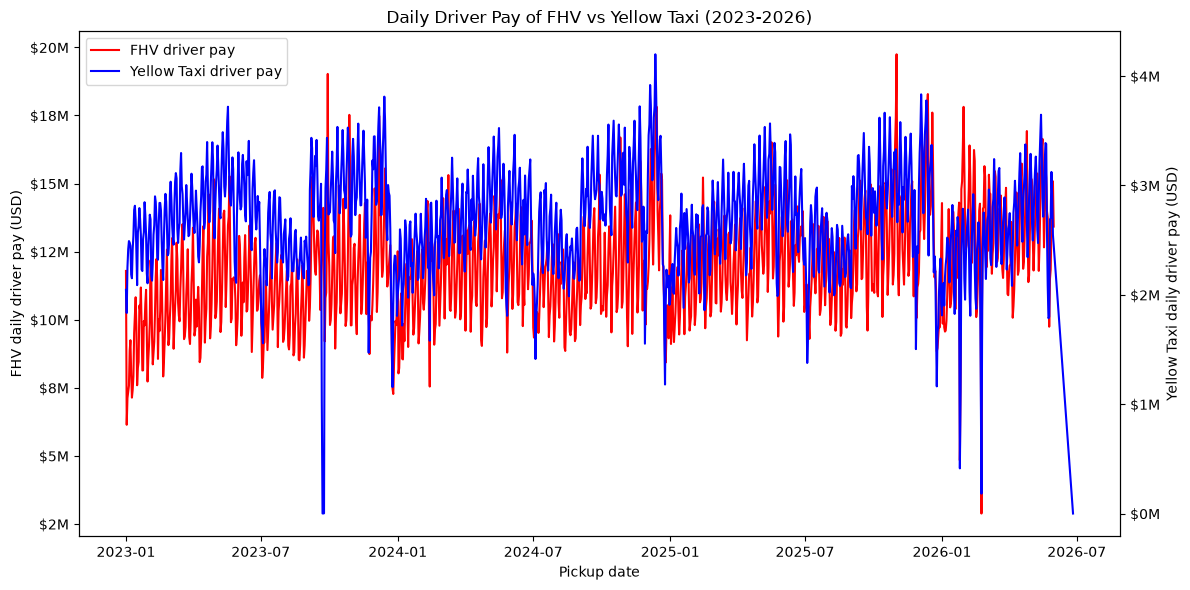

In [19]:
from matplotlib.ticker import FuncFormatter
# ---------------------------------------------------------
# Plot with TWO Y axes
# ---------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: FHV
line1 = ax1.plot(
    fhv_pd["date"],
    fhv_pd["driver_pay"],
    label="FHV driver pay",
    color="red"
)

ax1.set_xlabel("Pickup date")
ax1.set_ylabel("FHV daily driver pay (USD)")


# Right Y-axis: Yellow Taxi
ax2 = ax1.twinx()

line2 = ax2.plot(
    yellow_pd["date"],
    yellow_pd["driver_pay"],
    label="Yellow Taxi driver pay",
    color="blue"
)

ax2.set_ylabel("Yellow Taxi daily driver pay (USD)")


# ---------------------------------------------------------
# Combined legend
# ---------------------------------------------------------

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000000:,.0f}M"))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000000:,.0f}M"))
plt.title("Daily Driver Pay of FHV vs Yellow Taxi (2023-2026)")
plt.tight_layout()
plt.show()

In [20]:
# =========================================================
# 1. AGGREGATE YELLOW TAXI TO MONTHLY FREQUENCY
# =========================================================

yellow_monthly = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.sum(F.col("total_amount")).alias("average earnings")
    )
)


# =========================================================
# 2. AGGREGATE FHVHV TO MONTHLY FREQUENCY
# =========================================================

fhvhv_monthly = (
    fhvhv_taxi
    .filter(
        F.col("pickup_datetime").isNotNull() &
        F.col("driver_pay").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.sum(F.col("driver_pay")).alias("average earnings")
    )
)


# =========================================================
# 3. FIND TOP 10 FHVHV LOCATIONS
# =========================================================

fhvhv_top10 = (
    fhvhv_monthly
    .groupBy("PULocationID")
    .agg(
        F.avg(F.col("average earnings")).alias(
            "overall_average_earnings"
        )
    )
    .orderBy(
        F.col("overall_average_earnings").desc()
    )
    .limit(10)
)


# Show the top 10
fhvhv_top10.show()


# =========================================================
# 4. GET MONTHLY FHVHV DATA FOR TOP 10 LOCATIONS
# =========================================================

fhvhv_top10_monthly = (
    fhvhv_monthly
    .join(
        fhvhv_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 5. GET MONTHLY YELLOW TAXI DATA FOR THE SAME
#    TOP 10 FHVHV LOCATIONS
# =========================================================

yellow_top10_monthly = (
    yellow_monthly
    .join(
        fhvhv_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 6. CONVERT ONLY THE SMALL FINAL DATASETS TO PANDAS
# =========================================================

fhvhv_plot_pd = fhvhv_top10_monthly.toPandas()
yellow_plot_pd = yellow_top10_monthly.toPandas()


fhvhv_plot_pd["month"] = pd.to_datetime(
    fhvhv_plot_pd["month"]
)

yellow_plot_pd["month"] = pd.to_datetime(
    yellow_plot_pd["month"]
)


# =========================================================
# 7. GET THE TOP 10 LOCATION IDs
# =========================================================

locations = (
    fhvhv_top10
    .select("PULocationID")
    .rdd
    .flatMap(lambda x: x)
    .collect()
)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+------------+------------------------+
|PULocationID|overall_average_earnings|
+------------+------------------------+
|         132|     1.341481671804878E7|
|         138|     1.181662843121951E7|
|         230|       5347725.888536577|
|         161|       4860088.468780479|
|          79|      4564554.7148780385|
|         231|       4507744.372682921|
|          68|       4427928.832439017|
|          61|       4339338.385609745|
|         164|      4118188.0585365803|
|         246|      4057033.4002438965|
+------------+------------------------+



/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


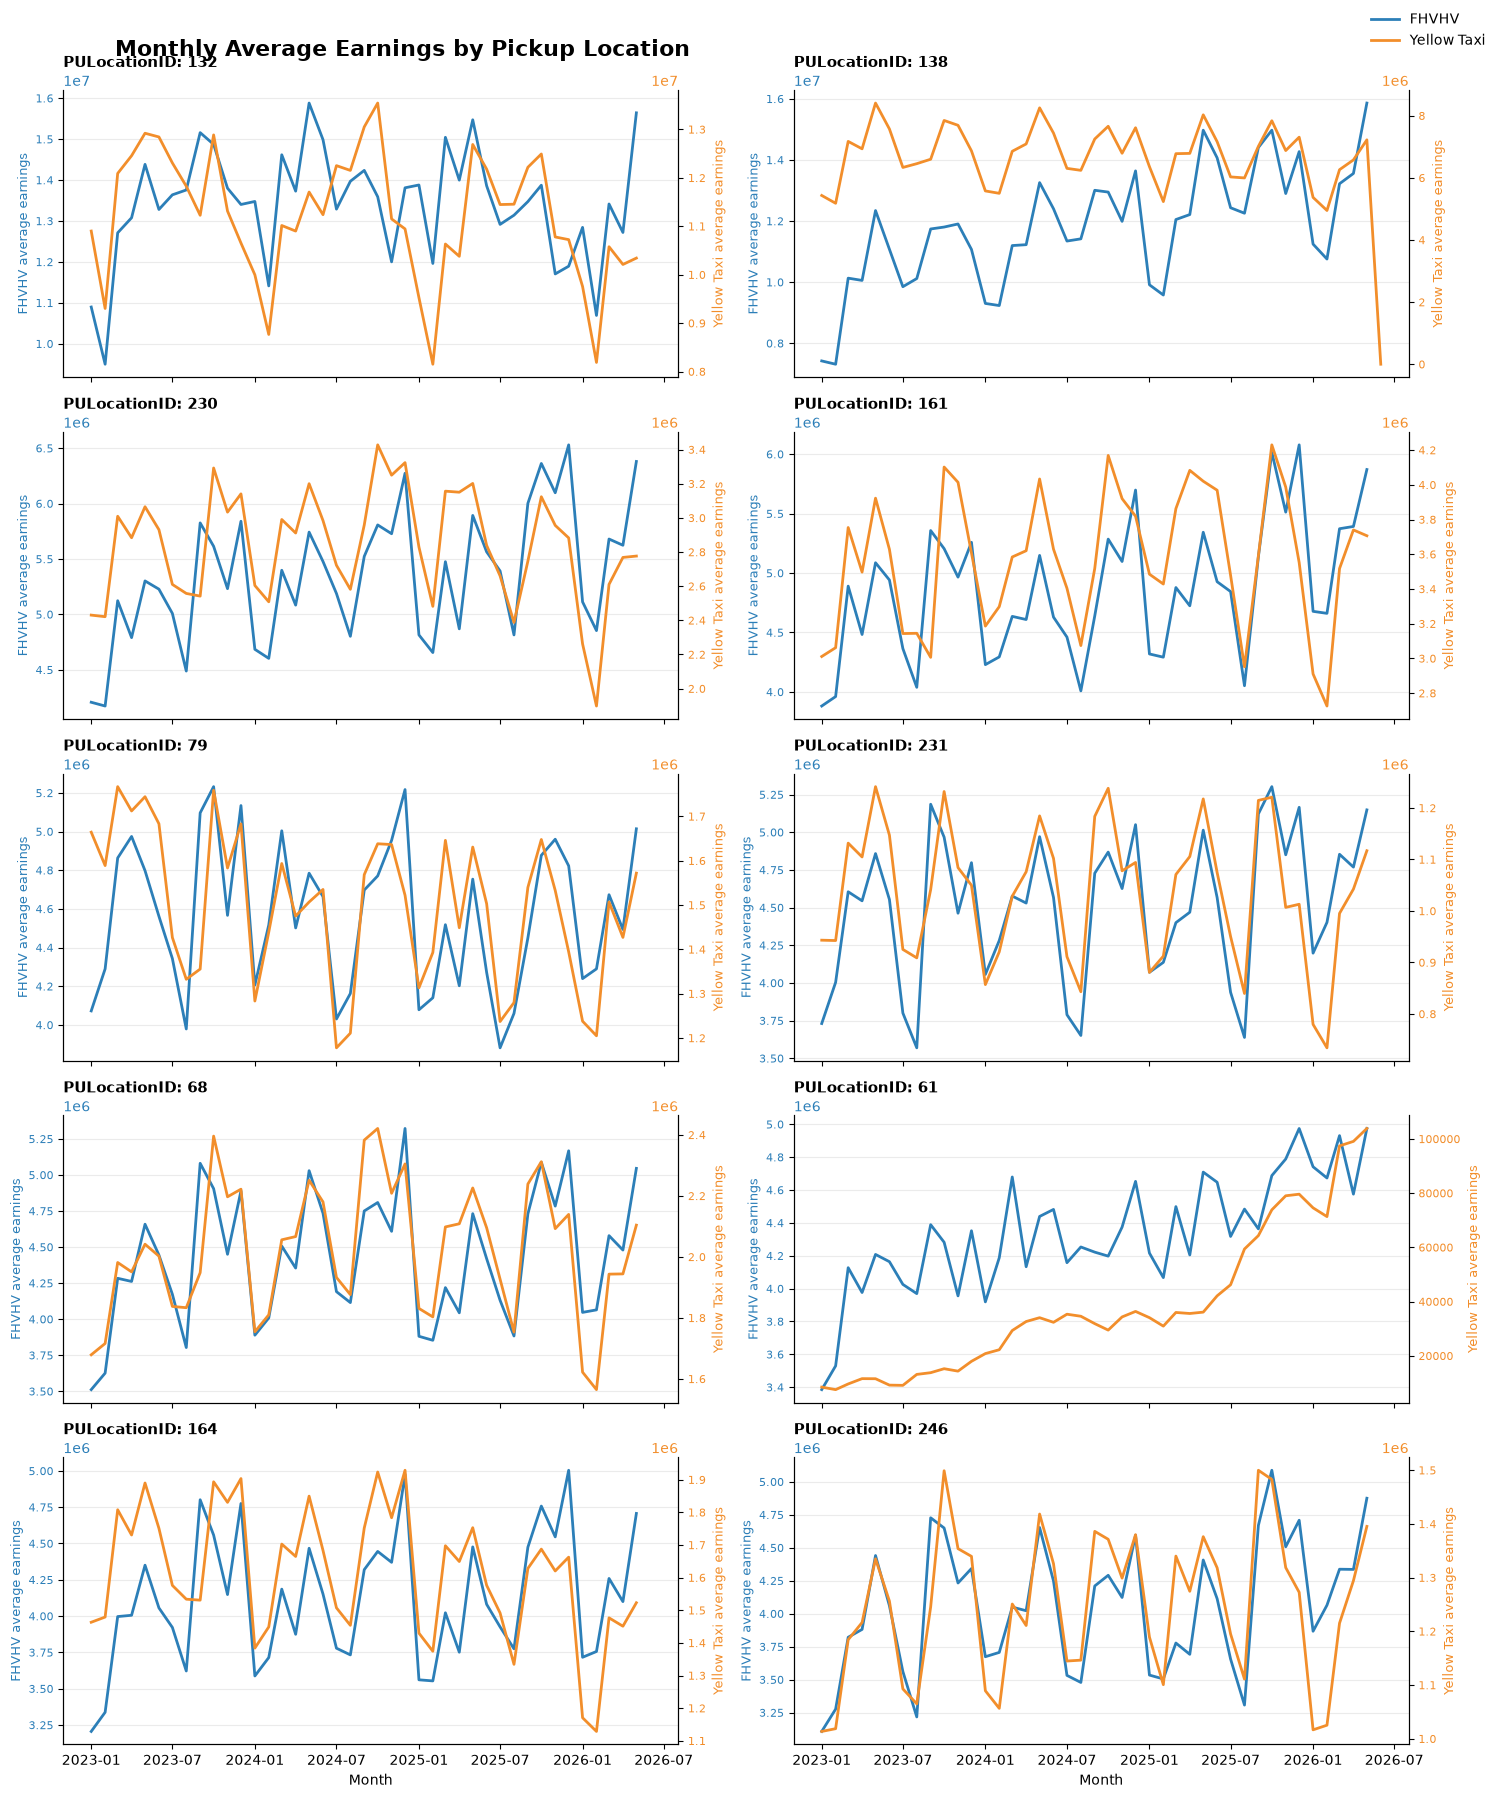

In [21]:
# =========================================================
# 8. CREATE 10 SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 18),
    sharex=True
)

axes = axes.flatten()


# =========================================================
# 9. PLOT FHVHV + YELLOW TAXI ON DUAL Y AXES
# =========================================================

for ax1, location in zip(axes, locations):

    # ---------------------------------------------
    # FHVHV data
    # ---------------------------------------------

    fhvhv_data = (
        fhvhv_plot_pd[
            fhvhv_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # Yellow Taxi data
    # ---------------------------------------------

    yellow_data = (
        yellow_plot_pd[
            yellow_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # LEFT Y-AXIS: FHVHV
    # ---------------------------------------------

    line1 = ax1.plot(
        fhvhv_data["month"],
        fhvhv_data["average earnings"],
        color="#2C7FB8",
        linewidth=2,
        label="FHVHV"
    )

    ax1.set_ylabel(
        "FHVHV average earnings",
        color="#2C7FB8",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#2C7FB8",
        labelsize=8
    )

    # ---------------------------------------------
    # RIGHT Y-AXIS: YELLOW TAXI
    # ---------------------------------------------

    ax2 = ax1.twinx()

    line2 = ax2.plot(
        yellow_data["month"],
        yellow_data["average earnings"],
        color="#F28E2B",
        linewidth=2,
        label="Yellow Taxi"
    )

    ax2.set_ylabel(
        "Yellow Taxi average earnings",
        color="#F28E2B",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#F28E2B",
        labelsize=8
    )

    # ---------------------------------------------
    # SUBPLOT TITLE
    # ---------------------------------------------

    ax1.set_title(
        f"PULocationID: {location}",
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    # ---------------------------------------------
    # GRID / CLEANUP
    # ---------------------------------------------

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    ax1.grid(
        axis="x",
        visible=False
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# =========================================================
# 10. X-AXIS LABELS
# =========================================================

for ax in axes[-2:]:
    ax.set_xlabel(
        "Month",
        fontsize=10
    )


# =========================================================
# 11. OVERALL TITLE
# =========================================================

fig.suptitle(
    "Monthly Average Earnings by Pickup Location",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    ha="left"
)


# =========================================================
# 12. ONE LEGEND FOR THE WHOLE FIGURE
# =========================================================

fig.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            color="#2C7FB8",
            linewidth=2,
            label="FHVHV"
        ),
        plt.Line2D(
            [0],
            [0],
            color="#F28E2B",
            linewidth=2,
            label="Yellow Taxi"
        )
    ],
    loc="upper right",
    frameon=False
)


plt.tight_layout()
plt.show()

In [22]:
# =========================================================
# 1. AGGREGATE YELLOW TAXI TO MONTHLY FREQUENCY
# =========================================================

yellow_monthly = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.avg(F.col("total_amount")).alias("average earnings")
    )
)


# =========================================================
# 2. AGGREGATE FHVHV TO MONTHLY FREQUENCY
# =========================================================

fhvhv_monthly = (
    fhvhv_taxi
    .filter(
        F.col("pickup_datetime").isNotNull() &
        F.col("driver_pay").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.avg(F.col("driver_pay")).alias("average earnings")
    )
)


# =========================================================
# 3. FIND TOP 10 YELLOW TAXI LOCATIONS
# =========================================================
# Yellow Taxi determines the top 10 zones here.

yellow_top10 = (
    yellow_monthly
    .groupBy("PULocationID")
    .agg(
        F.avg(F.col("average earnings")).alias(
            "overall_average_earnings"
        )
    )
    .orderBy(
        F.col("overall_average_earnings").desc()
    )
    .limit(10)
)


# Show the top 10 Yellow Taxi locations
yellow_top10.show()


# =========================================================
# 4. GET MONTHLY YELLOW TAXI DATA FOR TOP 10 LOCATIONS
# =========================================================

yellow_top10_monthly = (
    yellow_monthly
    .join(
        yellow_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 5. GET MONTHLY FHVHV DATA FOR THE SAME
#    TOP 10 YELLOW TAXI LOCATIONS
# =========================================================

fhvhv_top10_monthly = (
    fhvhv_monthly
    .join(
        yellow_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 6. CONVERT ONLY THE SMALL FINAL DATASETS TO PANDAS
# =========================================================

yellow_plot_pd = yellow_top10_monthly.toPandas()
fhvhv_plot_pd = fhvhv_top10_monthly.toPandas()


yellow_plot_pd["month"] = pd.to_datetime(
    yellow_plot_pd["month"]
)

fhvhv_plot_pd["month"] = pd.to_datetime(
    fhvhv_plot_pd["month"]
)


# =========================================================
# 7. GET THE TOP 10 LOCATION IDs
# =========================================================

locations = (
    yellow_top10
    .select("PULocationID")
    .rdd
    .flatMap(lambda x: x)
    .collect()
)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+------------+------------------------+
|PULocationID|overall_average_earnings|
+------------+------------------------+
|           1|       88.85070971288306|
|         204|       80.65666666666665|
|         132|       74.11016255529952|
|           5|       72.67732439758127|
|          10|       72.41969705647445|
|          93|       72.11221645225133|
|         138|       66.24853726543414|
|           8|       66.12125120907983|
|         219|       64.69773388025378|
|         251|        64.3740170068027|
+------------+------------------------+



/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


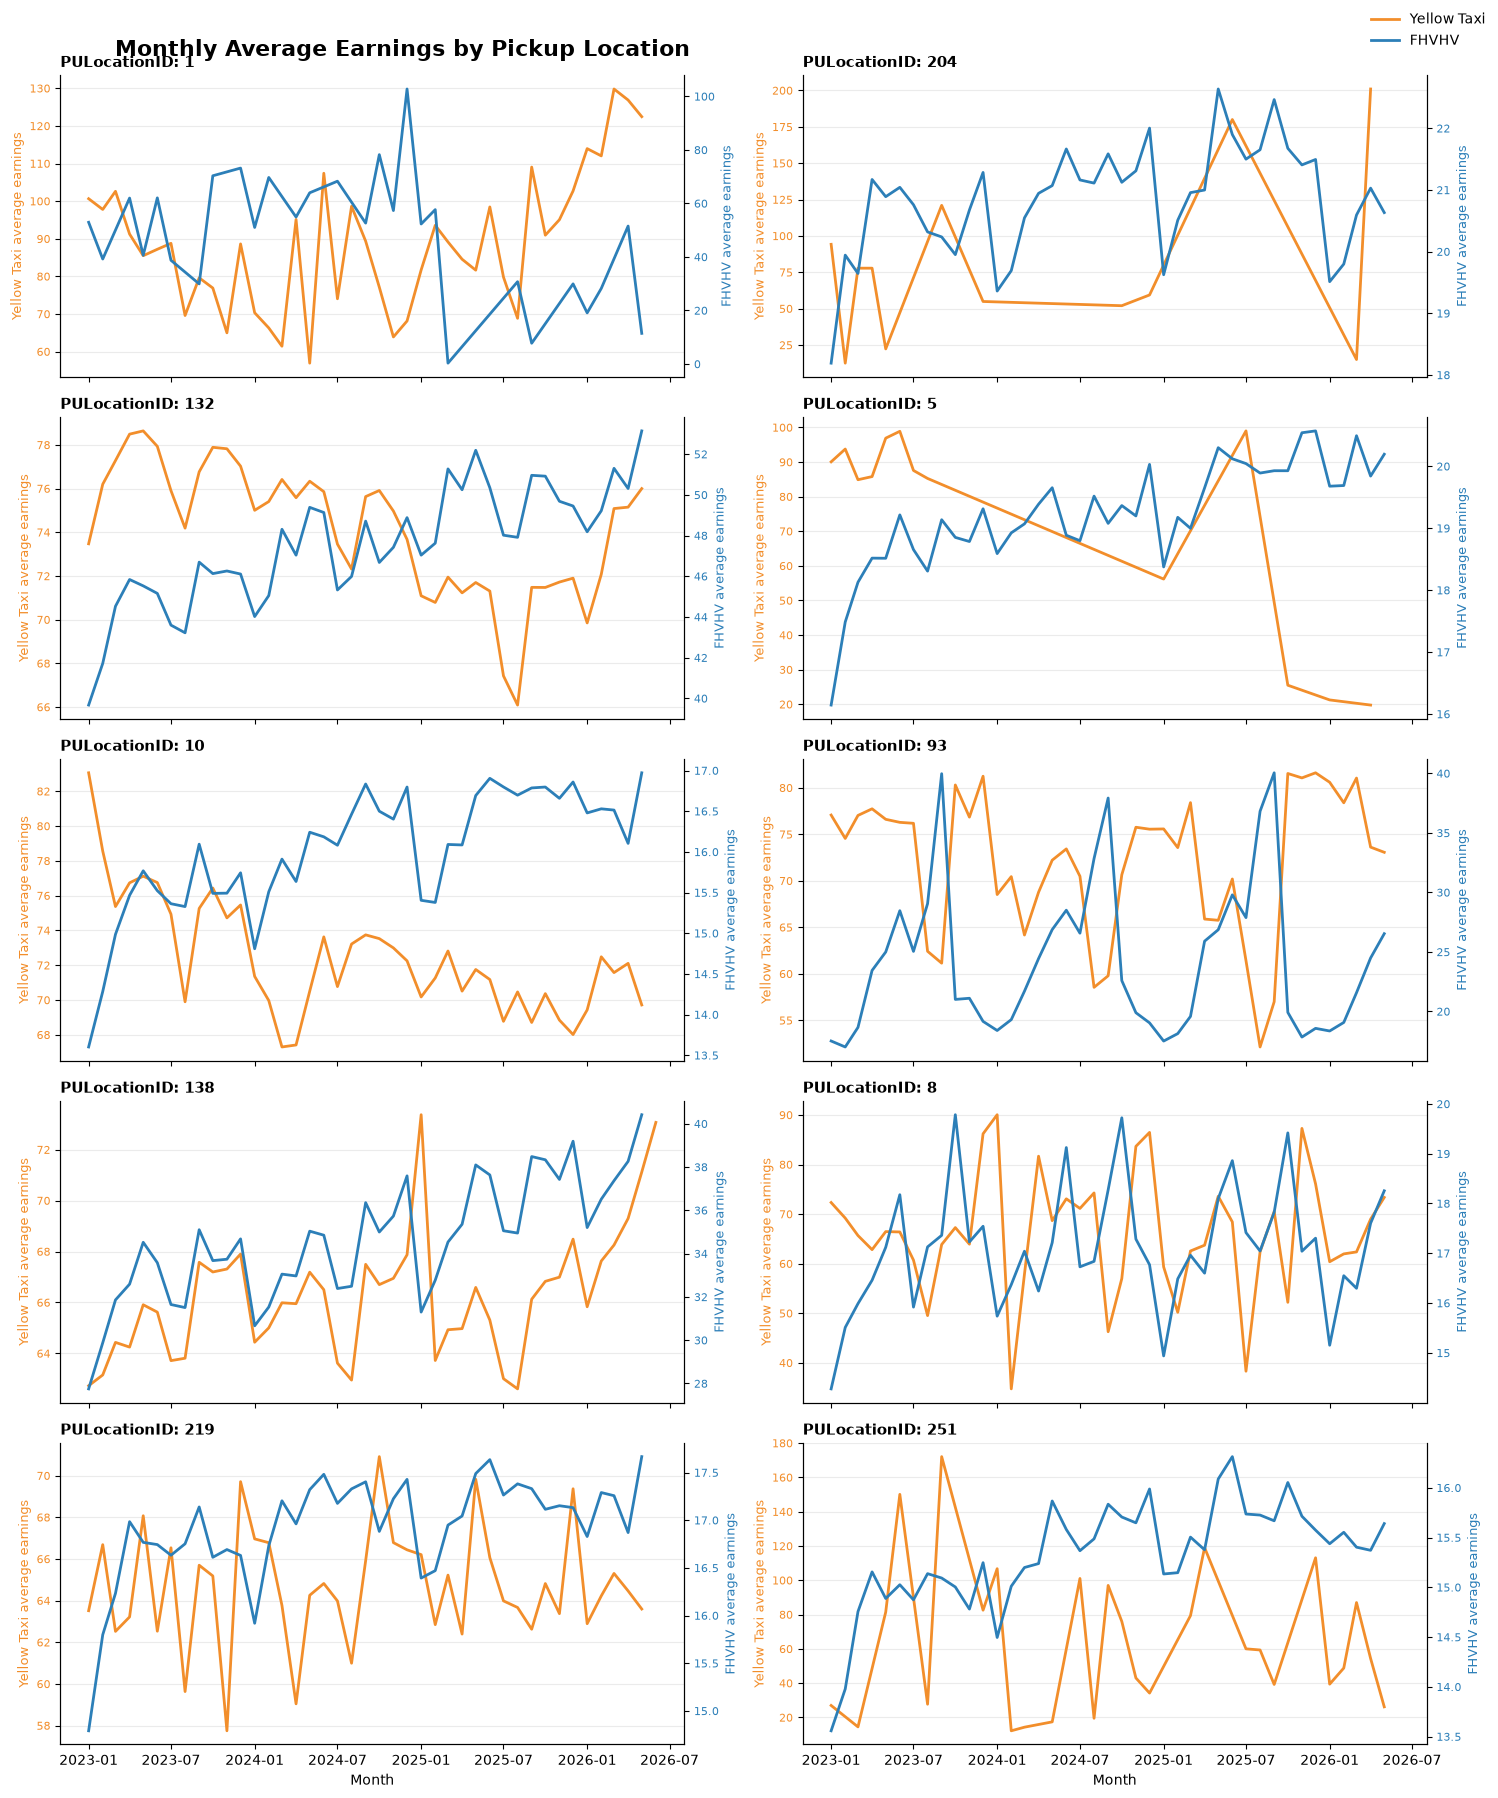

In [23]:
# =========================================================
# 8. CREATE 10 SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 18),
    sharex=True
)

axes = axes.flatten()


# =========================================================
# 9. PLOT YELLOW TAXI + FHVHV ON DUAL Y AXES
# =========================================================

for ax1, location in zip(axes, locations):

    # ---------------------------------------------
    # Yellow Taxi data
    # ---------------------------------------------

    yellow_data = (
        yellow_plot_pd[
            yellow_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # FHVHV data
    # ---------------------------------------------

    fhvhv_data = (
        fhvhv_plot_pd[
            fhvhv_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # LEFT Y-AXIS: YELLOW TAXI
    # ---------------------------------------------

    line1 = ax1.plot(
        yellow_data["month"],
        yellow_data["average earnings"],
        color="#F28E2B",
        linewidth=2,
        label="Yellow Taxi"
    )

    ax1.set_ylabel(
        "Yellow Taxi average earnings",
        color="#F28E2B",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#F28E2B",
        labelsize=8
    )

    # ---------------------------------------------
    # RIGHT Y-AXIS: FHVHV
    # ---------------------------------------------

    ax2 = ax1.twinx()

    line2 = ax2.plot(
        fhvhv_data["month"],
        fhvhv_data["average earnings"],
        color="#2C7FB8",
        linewidth=2,
        label="FHVHV"
    )

    ax2.set_ylabel(
        "FHVHV average earnings",
        color="#2C7FB8",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#2C7FB8",
        labelsize=8
    )

    # ---------------------------------------------
    # SUBPLOT TITLE
    # ---------------------------------------------

    ax1.set_title(
        f"PULocationID: {location}",
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    # ---------------------------------------------
    # GRID / CLEANUP
    # ---------------------------------------------

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    ax1.grid(
        axis="x",
        visible=False
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# =========================================================
# 10. X-AXIS LABELS
# =========================================================

for ax in axes[-2:]:
    ax.set_xlabel(
        "Month",
        fontsize=10
    )


# =========================================================
# 11. OVERALL TITLE
# =========================================================

fig.suptitle(
    "Monthly Average Earnings by Pickup Location",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    ha="left"
)


# =========================================================
# 12. ONE LEGEND FOR THE WHOLE FIGURE
# =========================================================

fig.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            color="#F28E2B",
            linewidth=2,
            label="Yellow Taxi"
        ),
        plt.Line2D(
            [0],
            [0],
            color="#2C7FB8",
            linewidth=2,
            label="FHVHV"
        )
    ],
    loc="upper right",
    frameon=False
)


plt.tight_layout()
plt.show()

In [24]:
zone_lookup = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)
zone_lookup.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


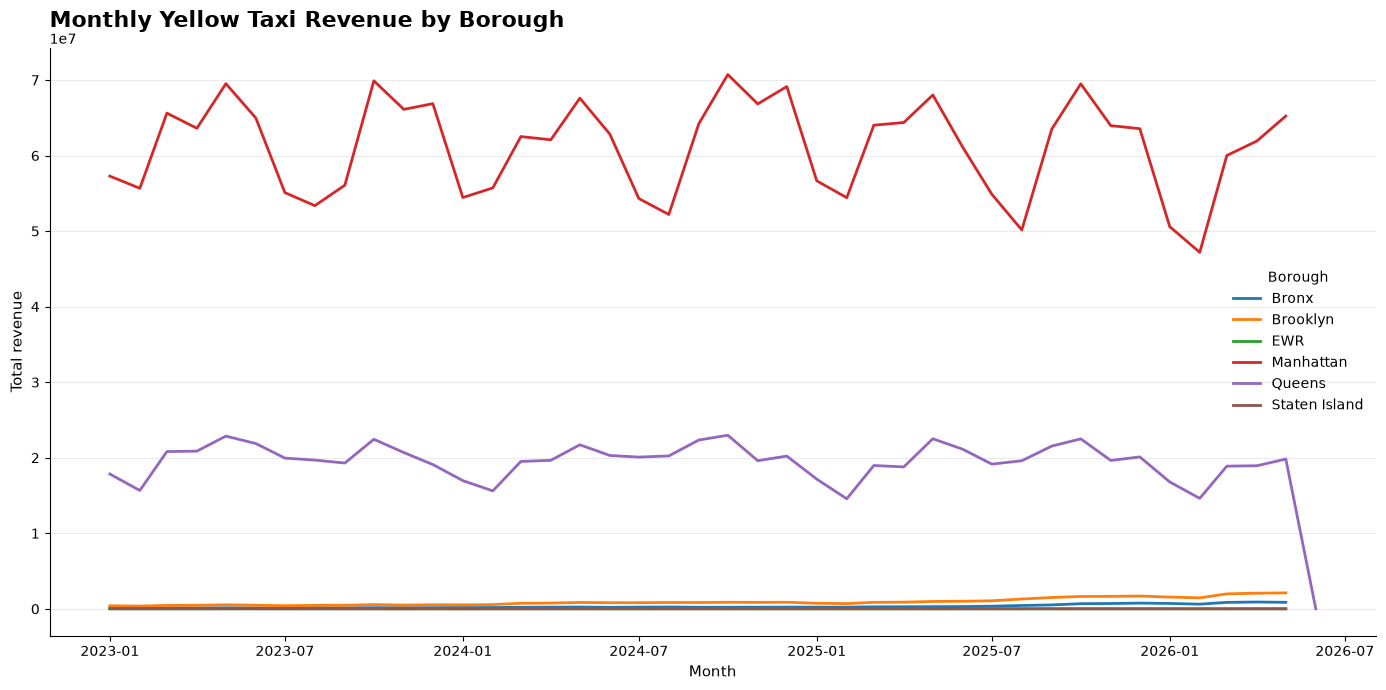

In [25]:
# =========================================================
# 1. PREPARE THE ZONE LOOKUP TABLE
# =========================================================

zone_lookup_clean = (
    zone_lookup
    .select(
        F.col("LocationID"),
        F.col("Borough")
    )
)


# =========================================================
# 2. JOIN YELLOW TAXI DATA TO BOROUGH INFORMATION
# =========================================================

yellow_with_borough = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .join(
        zone_lookup_clean,
        yellow_taxi["PULocationID"] == zone_lookup_clean["LocationID"],
        how="inner"
    )
)


# =========================================================
# 3. AGGREGATE TO MONTHLY TOTAL REVENUE BY BOROUGH
# =========================================================

borough_monthly_revenue = (
    yellow_with_borough
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("Borough")
    )
    .agg(
        F.sum(
            F.col("total_amount")
        ).alias("total_revenue")
    )
    .orderBy(
        "month",
        "Borough"
    )
)



# =========================================================
# 4. CONVERT THE SMALL AGGREGATED DATASET TO PANDAS
# =========================================================

borough_pd = borough_monthly_revenue.toPandas()

borough_pd["month"] = pd.to_datetime(
    borough_pd["month"]
)


# =========================================================
# 5. PLOT MONTHLY REVENUE FOR EACH BOROUGH
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


for borough in borough_pd["Borough"].unique():

    borough_data = (
        borough_pd[
            borough_pd["Borough"] == borough
        ]
        .sort_values("month")
    )

    ax.plot(
        borough_data["month"],
        borough_data["total_revenue"],
        linewidth=2,
        label=borough
    )


# =========================================================
# 6. CLEAN UP THE PLOT
# =========================================================

ax.set_title(
    "Monthly Yellow Taxi Revenue by Borough",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Total revenue",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Borough",
    frameon=False
)

plt.tight_layout()
plt.show()

In [19]:
X_yellow = (
    yellow_taxi

    # Keep valid timestamps, revenue, and pickup locations
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )

    # Extract calendar date
    .withColumn(
        "date",
        F.to_date("tpep_pickup_datetime")
    )

    # Day of week:
    # Monday = 1, Tuesday = 2, ..., Sunday = 7
    .withColumn(
        "day",
        ((F.dayofweek("tpep_pickup_datetime") + 5) % 7) + 1
    )

    # Numeric month:
    # January = 1, ..., December = 12
    .withColumn(
        "month",
        F.month("tpep_pickup_datetime")
    )

    # Aggregate daily revenue by pickup location
    .groupBy(
        "date",
        "day",
        "month",
        "PULocationID"
    )
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
)
# add a column called log_total_revenue that is the log of total_revenue + 1
X_yellow = X_yellow.withColumn("log_total_revenue", F.log1p(X_yellow.total_revenue))
print(X_yellow.count())
X_yellow.show()

270860


+----------+---+-----+------------+------------------+------------------+
|      date|day|month|PULocationID|     total_revenue| log_total_revenue|
+----------+---+-----+------------+------------------+------------------+
|2023-05-08|  1|    5|         186| 84532.24000000008|11.344900108775544|
|2023-05-02|  2|    5|         139|             180.0| 5.198497031265826|
|2023-05-03|  3|    5|         236|115552.53000000022|11.657489164781552|
|2023-05-03|  3|    5|          97| 583.4499999999999| 6.370671234053779|
|2023-05-03|  3|    5|         224|2860.6799999999994|  7.95916414394207|
|2023-05-05|  5|    5|         186| 85474.53000000023|11.355985415131745|
|2023-05-06|  6|    5|         260|            491.88| 6.200265736706315|
|2023-05-10|  3|    5|          24| 7546.660000000004| 8.928992860428838|
|2023-05-10|  3|    5|         194|             96.66| 4.581492058633514|
|2023-05-11|  4|    5|         143| 29651.54000000002|10.297303066861295|
|2023-05-11|  4|    5|         159|   

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


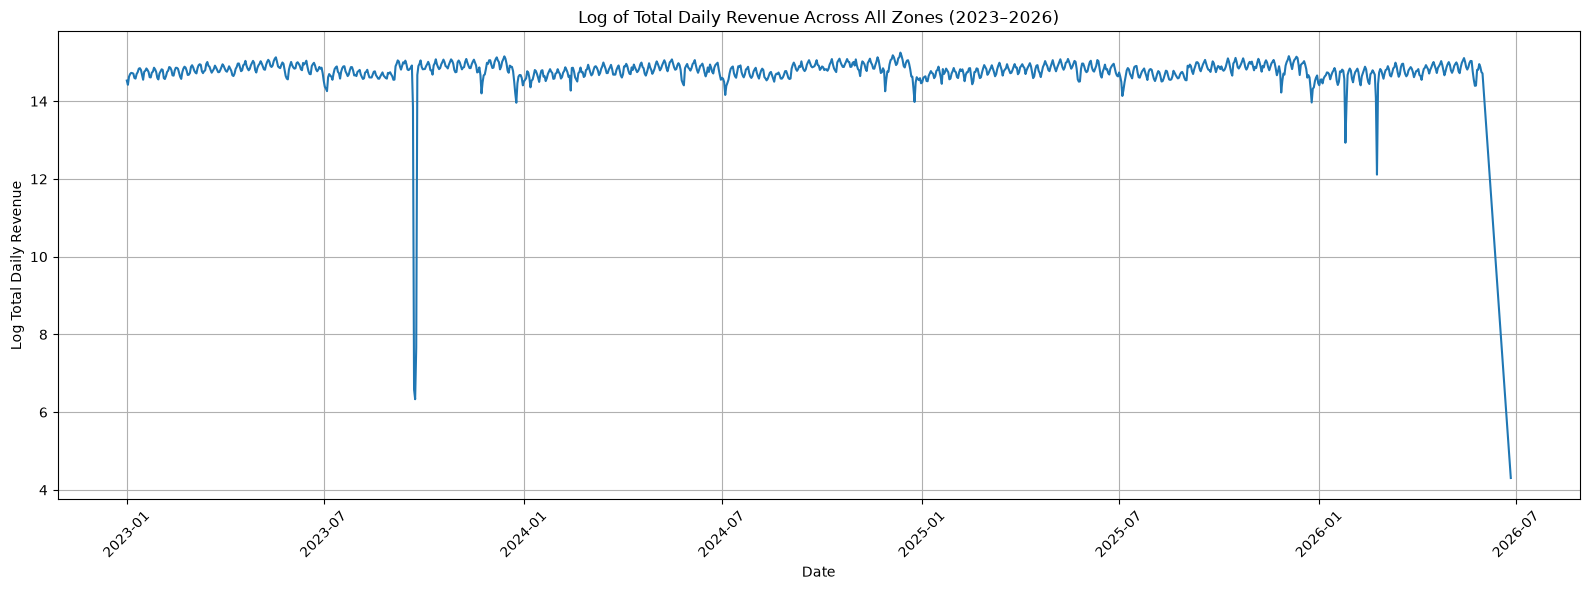

In [20]:
daily_revenue = (
    X_yellow
    .filter(
        (F.year("date") >= 2023) &
        (F.year("date") <= 2026)
    )
    .groupBy("date")
    .agg(
        F.sum("total_revenue").alias("daily_total_revenue")
    )
    .withColumn(
        "log_daily_total_revenue",
        F.log1p("daily_total_revenue")
    )
    .orderBy("date")
)

plot_data = daily_revenue.toPandas()

plt.figure(figsize=(16, 6))

plt.plot(
    plot_data["date"],
    plot_data["log_daily_total_revenue"]
)

plt.xlabel("Date")
plt.ylabel("Log Total Daily Revenue")
plt.title("Log of Total Daily Revenue Across All Zones (2023–2026)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Takeaways
No particular seasonal patterns on a quarterly or yearly basis. We may have to look at a more granular level. Weekly patterns are perhaps more likely eszone_activity.describe("activity_rate").show()pecially given the consistent rises and dips in the log daily revenue seen by the above plot.

In [22]:
from pyspark.sql import Window
# Get unique dates for each zone
zone_dates = (
    X_yellow
    .select("PULocationID", "date")
    .distinct()
)

# Previous date within each zone
window = (
    Window
    .partitionBy("PULocationID")
    .orderBy("date")
)

gaps = (
    zone_dates
    .withColumn(
        "previous_date",
        F.lag("date").over(window)
    )
    .withColumn(
        "days_since_previous",
        F.datediff("date", "previous_date")
    )
    .filter(
        F.col("days_since_previous") > 1
    )
    .orderBy(
        "PULocationID",
        "date"
    )
)

gaps.show(50, truncate=False)

+------------+----------+-------------+-------------------+
|PULocationID|date      |previous_date|days_since_previous|
+------------+----------+-------------+-------------------+
|1           |2023-01-05|2023-01-02   |3                  |
|1           |2023-01-09|2023-01-06   |3                  |
|1           |2023-01-12|2023-01-09   |3                  |
|1           |2023-01-20|2023-01-17   |3                  |
|1           |2023-01-24|2023-01-20   |4                  |
|1           |2023-01-27|2023-01-24   |3                  |
|1           |2023-02-03|2023-01-27   |7                  |
|1           |2023-02-07|2023-02-03   |4                  |
|1           |2023-02-12|2023-02-07   |5                  |
|1           |2023-02-14|2023-02-12   |2                  |
|1           |2023-02-16|2023-02-14   |2                  |
|1           |2023-02-23|2023-02-19   |4                  |
|1           |2023-02-27|2023-02-24   |3                  |
|1           |2023-03-06|2023-03-02   |4

In [23]:
gaps.orderBy(
    F.desc("days_since_previous")
).show(20, truncate=False)

+------------+----------+-------------+-------------------+
|PULocationID|date      |previous_date|days_since_previous|
+------------+----------+-------------+-------------------+
|5           |2025-01-02|2023-08-20   |501                |
|84          |2024-10-02|2023-06-07   |483                |
|84          |2025-09-29|2024-10-30   |334                |
|99          |2024-12-18|2024-02-11   |311                |
|204         |2024-10-10|2023-12-11   |304                |
|187         |2024-11-28|2024-03-01   |272                |
|204         |2026-03-01|2025-06-04   |270                |
|176         |2025-09-29|2025-01-04   |268                |
|109         |2024-08-27|2023-12-07   |264                |
|44          |2025-06-24|2024-10-12   |255                |
|245         |2023-12-03|2023-04-07   |240                |
|176         |2024-09-05|2024-01-09   |240                |
|115         |2024-04-28|2023-10-13   |198                |
|5           |2025-07-11|2025-01-02   |1

In [24]:
zone_summary = (
    X_yellow
    .groupBy("PULocationID")
    .agg(
        F.countDistinct("date").alias("active_days"),
        F.min("date").alias("first_date"),
        F.max("date").alias("last_date"),
        F.sum("total_revenue").alias("total_revenue")
    )
    .orderBy("active_days")
)

zone_summary.show(20, truncate=False)

+------------+-----------+----------+----------+------------------+
|PULocationID|active_days|first_date|last_date |total_revenue     |
+------------+-----------+----------+----------+------------------+
|99          |10         |2023-04-28|2025-10-06|623.06            |
|204         |12         |2023-01-09|2026-04-26|967.8800000000001 |
|84          |14         |2023-03-12|2026-05-07|779.7100000000002 |
|187         |17         |2023-05-12|2026-05-17|919.06            |
|105         |25         |2023-02-16|2026-05-28|1017.0199999999999|
|245         |27         |2023-01-24|2026-05-06|1087.7199999999998|
|176         |31         |2023-03-04|2026-04-23|1159.24           |
|115         |34         |2023-02-05|2026-05-18|2101.09           |
|109         |35         |2023-01-07|2026-04-11|2187.18           |
|156         |42         |2023-01-10|2026-05-10|2899.83           |
|251         |54         |2023-01-29|2026-05-30|3829.3900000000003|
|199         |58         |2023-01-04|2026-05-23|

In [25]:
total_days = 1096 + 31 + 28 + 30 + 31 + 30
zone_activity = (
    X_yellow
    .select("PULocationID", "date")
    .distinct()
    .groupBy("PULocationID")
    .agg(
        F.count("*").alias("active_days")
    )
    .withColumn(
        "activity_rate",
        F.col("active_days") / total_days
    )
    .orderBy("activity_rate")
)

zone_activity.show(100, truncate=False)

+------------+-----------+--------------------+
|PULocationID|active_days|activity_rate       |
+------------+-----------+--------------------+
|99          |10         |0.008025682182985553|
|204         |12         |0.009630818619582664|
|84          |14         |0.011235955056179775|
|187         |17         |0.013643659711075442|
|105         |25         |0.020064205457463884|
|245         |27         |0.021669341894060994|
|176         |31         |0.024879614767255216|
|115         |34         |0.027287319422150885|
|109         |35         |0.028089887640449437|
|156         |42         |0.033707865168539325|
|251         |54         |0.04333868378812199 |
|199         |58         |0.04654895666131621 |
|172         |65         |0.0521669341894061  |
|206         |70         |0.056179775280898875|
|221         |76         |0.060995184590690206|
|30          |84         |0.06741573033707865 |
|118         |99         |0.07945425361155699 |
|111         |111        |0.089085072231

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


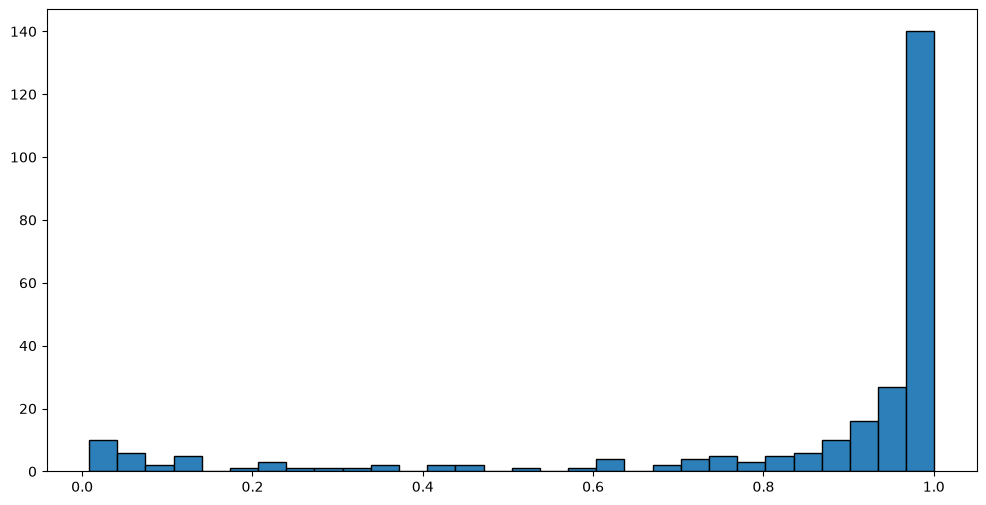

In [26]:
# plot a histogram of the activity_rate column
activity_rate_pd = zone_activity.toPandas()
plt.figure(figsize=(12, 6))
plt.hist(
    activity_rate_pd["activity_rate"],
    bins=30,
    color="#2C7FB8",
    edgecolor="black"
)
plt.show()

In [27]:
# ============================================================
# 1. Calculate activity rate for each zone
# ============================================================

# Full date range in X_yellow
date_range = (
    X_yellow
    .select(
        F.min("date").alias("min_date"),
        F.max("date").alias("max_date")
    )
    .first()
)

min_date = date_range["min_date"]
max_date = date_range["max_date"]

# Number of calendar days in the dataset
total_days = (
    (max_date - min_date).days + 1
)

# Number of days on which each zone was active
zone_activity = (
    X_yellow
    .select("PULocationID", "date")
    .distinct()
    .groupBy("PULocationID")
    .agg(
        F.count("*").alias("active_days")
    )
    .withColumn(
        "activity_rate",
        F.col("active_days") / F.lit(total_days)
    )
)

# Zones with at least 80% activity
zones_80 = (
    zone_activity
    .filter(F.col("activity_rate") >= 0.80)
    .select("PULocationID")
)

print(
    f"Total zones: {zone_activity.count()}"
)

print(
    f"Zones with >= 80% activity: {zones_80.count()}"
)


# ============================================================
# 2. Create lag features for ALL zones
# ============================================================

zone_window = (
    Window
    .partitionBy("PULocationID")
    .orderBy("date")
)

X_yellow_lags = (
    X_yellow
    .withColumn(
        "lag_1_log_total_revenue",
        F.lag("log_total_revenue", 1).over(zone_window)
    )
    .withColumn(
        "lag_7_log_total_revenue",
        F.lag("log_total_revenue", 7).over(zone_window)
    )
    .withColumn(
        "lag_14_log_total_revenue",
        F.lag("log_total_revenue", 14).over(zone_window)
    )
)


# ============================================================
# 3. Correlations using ALL zones
# ============================================================

corr_lag_1_all = (
    X_yellow_lags
    .select(
        "log_total_revenue",
        "lag_1_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_1_log_total_revenue"
    )
)

corr_lag_7_all = (
    X_yellow_lags
    .select(
        "log_total_revenue",
        "lag_7_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_7_log_total_revenue"
    )
)

corr_lag_14_all = (
    X_yellow_lags
    .select(
        "log_total_revenue",
        "lag_14_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_14_log_total_revenue"
    )
)


# ============================================================
# 4. Filter to zones with >= 80% activity
# ============================================================

X_yellow_80 = (
    X_yellow_lags
    .join(
        zones_80,
        on="PULocationID",
        how="inner"
    )
)


# ============================================================
# 5. Correlations using ONLY >=80% activity zones
# ============================================================

corr_lag_1_80 = (
    X_yellow_80
    .select(
        "log_total_revenue",
        "lag_1_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_1_log_total_revenue"
    )
)

corr_lag_7_80 = (
    X_yellow_80
    .select(
        "log_total_revenue",
        "lag_7_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_7_log_total_revenue"
    )
)

corr_lag_14_80 = (
    X_yellow_80
    .select(
        "log_total_revenue",
        "lag_14_log_total_revenue"
    )
    .na.drop()
    .stat.corr(
        "log_total_revenue",
        "lag_14_log_total_revenue"
    )
)

# ============================================================
# 6. Print comparison
# ============================================================

print("\nCorrelation with log_total_revenue")
print("=" * 65)
print(f"{'Lag':<10} {'All zones':>15} {'>=80% activity':>20}")
print("-" * 65)

print(
    f"{'Lag-1':<10} "
    f"{corr_lag_1_all:>15.4f} "
    f"{corr_lag_1_80:>20.4f}"
)

print(
    f"{'Lag-7':<10} "
    f"{corr_lag_7_all:>15.4f} "
    f"{corr_lag_7_80:>20.4f}"
)

print(
    f"{'Lag-14':<10} "
    f"{corr_lag_14_all:>15.4f} "
    f"{corr_lag_14_80:>20.4f}"
)

Total zones: 260


Zones with >= 80% activity: 202



Correlation with log_total_revenue
Lag              All zones       >=80% activity
-----------------------------------------------------------------
Lag-1               0.9465               0.9514
Lag-7               0.9500               0.9556
Lag-14              0.9472               0.9522


# Next steps
We will create the full date x zone formulation for our data so that we don't miss any days. New days that come up will have their revenue set to 0 as a simple assumption that there is no demand (at least significantly) to be had in those areas on those days.

In [28]:
# ============================================================
# 1. Get the full date range
# ============================================================

date_range = (
    X_yellow
    .select(
        F.min("date").alias("min_date"),
        F.max("date").alias("max_date")
    )
    .first()
)

min_date = date_range["min_date"]
max_date = date_range["max_date"]


# ============================================================
# 2. Create every date in the dataset
# ============================================================

dates = (
    X_yellow.sparkSession
    .range(1)
    .select(
        F.explode(
            F.sequence(
                F.lit(min_date),
                F.lit(max_date),
                F.expr("interval 1 day")
            )
        ).alias("date")
    )
)


# ============================================================
# 3. Get all PULocationIDs
# ============================================================

zones = (
    X_yellow
    .select("PULocationID")
    .distinct()
)


# ============================================================
# 4. Create complete date × zone grid
# ============================================================

date_zone_panel = (
    dates
    .crossJoin(zones)
)


# ============================================================
# 5. Aggregate Yellow revenue by date + zone
# ============================================================

yellow_daily = (
    X_yellow
    .groupBy(
        "date",
        "PULocationID"
    )
    .agg(
        F.sum("total_revenue").alias("total_revenue")
    )
)


# ============================================================
# 6. Join revenue onto the complete panel
# ============================================================

X_yellow_complete = (
    date_zone_panel
    .join(
        yellow_daily,
        on=["date", "PULocationID"],
        how="left"
    )
    .fillna({
        "total_revenue": 0.0
    })
)


# ============================================================
# 7. Create log revenue
# ============================================================

X_yellow_complete = (
    X_yellow_complete
    .withColumn(
        "log_total_revenue",
        F.log1p("total_revenue")
    )
)


# ============================================================
# 8. Create proper calendar-based lags
# ============================================================

zone_window = (
    Window
    .partitionBy("PULocationID")
    .orderBy("date")
)

X_yellow_complete = (
    X_yellow_complete
    .withColumn(
        "lag_1_log_total_revenue",
        F.lag(
            "log_total_revenue",
            1
        ).over(zone_window)
    )
    .withColumn(
        "lag_7_log_total_revenue",
        F.lag(
            "log_total_revenue",
            7
        ).over(zone_window)
    )
    .withColumn(
        "lag_14_log_total_revenue",
        F.lag(
            "log_total_revenue",
            14
        ).over(zone_window)
    )
)
print(X_yellow_complete.count())

330980


In [29]:
# check that the number of rows in X_yellow_complete is equal to the number of unique zones multiplied by the number of unique dates
# Number of unique zones
num_zones = zones.count()

# Number of calendar days
num_days = dates.count()

# Expected number of rows
expected_rows = num_zones * num_days

# Actual number of rows
actual_rows = X_yellow_complete.count()

print("Number of zones:", num_zones)
print("Number of days:", num_days)
print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)
print("Panel complete:", expected_rows == actual_rows)

Number of zones: 260
Number of days: 1273
Expected rows: 330980
Actual rows: 330980
Panel complete: True


# Takeaways
A lag of 7 days seems like the most predictive of target, likely due to weekly seasonal patterns in taxi earnings. However, all three lags are strong predictors of the log total revenue and so it would be wise to not pick all three lags since they are likely highly correlated with each other. This is made clear by the correlation matrix below.

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


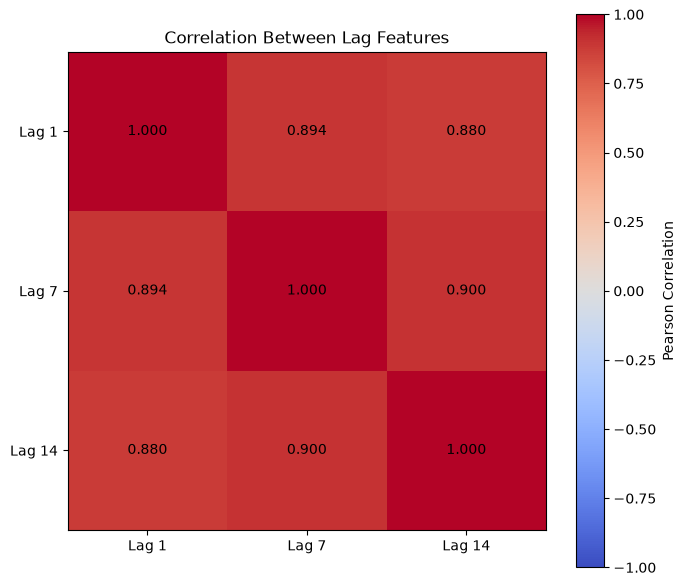

In [30]:
# Select the three lag features
lag_columns = [
    "lag_1_log_total_revenue",
    "lag_7_log_total_revenue",
    "lag_14_log_total_revenue"
]

# Convert to Pandas and calculate correlation matrix
corr_matrix = (
    X_yellow_complete
    .select(lag_columns)
    .dropna()
    .toPandas()
    .corr()
)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add correlation values to each cell
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

# Axis labels
ax.set_xticks(range(len(corr_matrix)))
ax.set_yticks(range(len(corr_matrix)))

ax.set_xticklabels([
    "Lag 1",
    "Lag 7",
    "Lag 14"
])

ax.set_yticklabels([
    "Lag 1",
    "Lag 7",
    "Lag 14"
])

ax.set_title("Correlation Between Lag Features")

fig.colorbar(im, ax=ax, label="Pearson Correlation")

plt.tight_layout()
plt.show()

# Takeaway
Correlation between the three lags is extremely high so we will stick to using a single lag feature, most likely lag 7. 

In [31]:
X_fhvhv = fhvhv_taxi
# ============================================================
# 1. Aggregate FH-VHV driver pay to daily, by PULocationID
# ============================================================

X_fhvhv_daily = (
    X_fhvhv
    .withColumn(
        "date",
        F.to_date("pickup_datetime")
    )
    .groupBy(
        "date",
        "PULocationID"
    )
    .agg(
        F.sum("driver_pay").alias("driver_pay")
    )
    .withColumn(
        "log_driver_pay",
        F.log("driver_pay")
    )
)

print(X_fhvhv_daily.count())
yellow_dates = (
    X_yellow
    .select(
        F.min("date").alias("min_date"),
        F.max("date").alias("max_date")
    )
    .first()
)

yellow_start = yellow_dates["min_date"]
yellow_end = yellow_dates["max_date"]

X_fhvhv_daily_common = (
    X_fhvhv_daily
    .filter(
        (F.col("date") >= yellow_start) &
        (F.col("date") <= yellow_end)
    )
)

X_fhvhv_daily_common.select(
    F.min("date").alias("min_date"),
    F.max("date").alias("max_date")
).show()

# Create all dates in the Yellow Taxi analysis period
dates_fhvhv = (
    X_yellow.sparkSession
    .range(1)
    .select(
        F.explode(
            F.sequence(
                F.lit(yellow_start),
                F.lit(yellow_end),
                F.expr("interval 1 day")
            )
        ).alias("date")
    )
)

# FH-VHV zones
zones_fhvhv = (
    X_fhvhv_daily_common
    .select("PULocationID")
    .distinct()
)

# Complete FH-VHV date × zone panel
fhvhv_date_zone_panel = (
    dates_fhvhv
    .crossJoin(zones_fhvhv)
)

# Add driver pay
X_fhvhv_complete = (
    fhvhv_date_zone_panel
    .join(
        X_fhvhv_daily_common,
        on=["date", "PULocationID"],
        how="left"
    )
    .fillna({
        "driver_pay": 0.0
    })
    .withColumn(
        "log_driver_pay",
        F.log1p("driver_pay")
    )
)
print(X_fhvhv_complete.count())

320521


+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2023-01-01|2026-05-31|
+----------+----------+



330980


In [32]:
# calculate the same lag features
# Window: ordered chronologically within each PULocationID
fhvhv_zone_window = (
    Window
    .partitionBy("PULocationID")
    .orderBy("date")
)

# Create lag features from log_driver_pay
X_fhvhv_complete = (
    X_fhvhv_complete
    .withColumn(
        "lag_1_log_driver_pay",
        F.lag("log_driver_pay", 1).over(fhvhv_zone_window)
    )
    .withColumn(
        "lag_7_log_driver_pay",
        F.lag("log_driver_pay", 7).over(fhvhv_zone_window)
    )
    .withColumn(
        "lag_14_log_driver_pay",
        F.lag("log_driver_pay", 14).over(fhvhv_zone_window)
    )
)

In [33]:
combined = (
    X_yellow_complete
    .join(
        X_fhvhv_complete,
        on=["date", "PULocationID"],
        how="left"
    )
)
combined.show()

+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|      date|PULocationID|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|2023-01-04|           4|            748.31| 6.619152783070614|       6.58606130393865|                   NULL|                    NULL|18806.309999999983| 9.842000903030561|   9.773759204874338|                NULL|                 NULL|
|2023-01-07|           1|               0.0|

In [34]:
# save the combined dataset to a parquet file
combined.write.mode("overwrite").parquet("training_data/combined_yellow_fhvhv.parquet")

In [61]:
flight_data = spark.read.csv('data/airport_traffic_data.csv', header=True, inferSchema=True)
flight_data.printSchema()

root
 |-- Activity Period: timestamp (nullable = true)
 |-- Airport Code: string (nullable = true)
 |-- Terminal Port: string (nullable = true)
 |-- Marketing Airline Name: string (nullable = true)
 |-- Direction: string (nullable = true)
 |-- Market: string (nullable = true)
 |-- World Region: string (nullable = true)
 |-- Revenue Passenger Volume: integer (nullable = true)
 |-- Non-Revenue Passenger Volume: integer (nullable = true)
 |-- Freight Volume: double (nullable = true)
 |-- Mail Volume: double (nullable = true)
 |-- Total Flights: integer (nullable = true)



In [66]:
# filter down to passenger flights
# within the desired time interval, and only inbound flights
passenger_flights = (
    flight_data
    .filter(
        (F.col('Revenue Passenger Volume') > 0) &
        (F.col('direction') == 'Inbound') & 
        (F.col('Activity Period') >= '2023-01-01') &
        (F.col('Activity Period') <= '2026-06-26') & 
        (F.col('Airport Code').isin(['JFK', 'LGA', 'EWR']))
    )
)
passenger_flights = passenger_flights.withColumn(
    "date",
    F.to_date(F.col("Activity Period"), "yyyy-MM-dd")
)
passenger_flights = passenger_flights.drop("Activity Period")
passenger_flights.show()

+------------+-------------+----------------------+---------+-------------+--------------------+------------------------+----------------------------+--------------+-----------+-------------+----------+
|Airport Code|Terminal Port|Marketing Airline Name|Direction|       Market|        World Region|Revenue Passenger Volume|Non-Revenue Passenger Volume|Freight Volume|Mail Volume|Total Flights|      date|
+------------+-------------+----------------------+---------+-------------+--------------------+------------------------+----------------------------+--------------+-----------+-------------+----------+
|         LGA|   TERMINAL C|                 DELTA|  Inbound|     Domestic|            DOMESTIC|                  567130|                       14114|        4.3625|        0.0|         6657|2024-07-01|
|         EWR|   TERMINAL B|            AIR FRANCE|  Inbound|International|       TRANSATLANTIC|                    8477|                         122|       372.973|        0.0|           

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


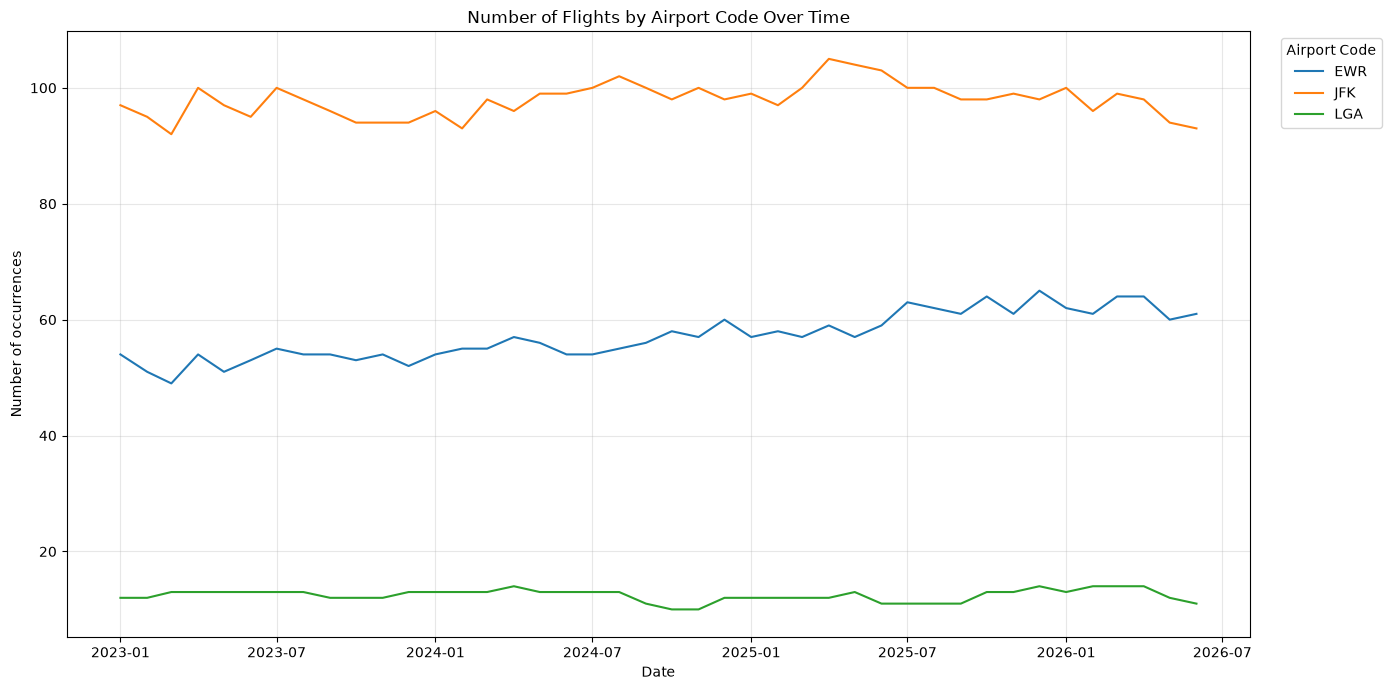

In [67]:
# Aggregate number of occurrences by date and Airport Code
daily_counts = (
    passenger_flights
    .groupBy("date", "Airport Code")
    .count()
    .orderBy("date")
)

# Bring the relatively small aggregated result to Pandas
plot_df = daily_counts.toPandas()

# Make sure date is a proper datetime
plot_df["date"] = pd.to_datetime(plot_df["date"])

# Pivot so each Airport Code becomes a separate series
plot_data = plot_df.pivot(
    index="date",
    columns="Airport Code",
    values="count"
).fillna(0)

# Plot
plt.figure(figsize=(14, 7))

for airport in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[airport],
        label=airport
    )

plt.xlabel("Date")
plt.ylabel("Number of occurrences")
plt.title("Number of Flights by Airport Code Over Time")
plt.legend(title="Airport Code", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
money_stats = combined.filter(F.col('PULocationID').isin([132, 138, 1])).select('date', 'PULocationID', 'log_total_revenue')
money_stats = money_stats.groupby(F.date_trunc('month', 'date').alias('date'), 'PULocationID').agg(F.sum('log_total_revenue').alias('total_log_revenue')).orderBy('date', 'PULocationID')
print(money_stats.count())
money_stats.show(10)

126


+-------------------+------------+------------------+
|               date|PULocationID| total_log_revenue|
+-------------------+------------+------------------+
|2023-01-01 00:00:00|           1| 62.90569991428714|
|2023-01-01 00:00:00|         132|395.52150975908665|
|2023-01-01 00:00:00|         138| 373.5295874661698|
|2023-02-01 00:00:00|           1|56.303121585206135|
|2023-02-01 00:00:00|         132| 355.7021224727913|
|2023-02-01 00:00:00|         138| 338.8676835614447|
|2023-03-01 00:00:00|           1| 85.56436396500621|
|2023-03-01 00:00:00|         132| 398.8821159328657|
|2023-03-01 00:00:00|         138| 382.1823937547461|
|2023-04-01 00:00:00|           1|57.877600623253635|
+-------------------+------------+------------------+
only showing top 10 rows


In [151]:
airport_stats = passenger_flights.filter(F.col('Airport Code').isin(['JFK', 'LGA', 'EWR'])).select('date', 'Airport Code', 'Revenue Passenger Volume')
airport_stats = airport_stats.withColumn('PULocationID', F.when(F.col('Airport Code') == 'JFK', 132).when(F.col('Airport Code') == 'LGA', 138).when(F.col('Airport Code') == 'EWR', 1)).drop('Airport Code')
airport_stats = airport_stats.groupby(F.date_trunc('month', 'date').alias('date'), 'PULocationID').agg(F.sum('Revenue Passenger Volume').alias('total_passengers')).orderBy('date', 'PULocationID')
print(airport_stats.count())
airport_stats.show(10)

126
+-------------------+------------+----------------+
|               date|PULocationID|total_passengers|
+-------------------+------------+----------------+
|2023-01-01 00:00:00|           1|         1801687|
|2023-01-01 00:00:00|         132|         2273636|
|2023-01-01 00:00:00|         138|         1096140|
|2023-02-01 00:00:00|           1|         1678787|
|2023-02-01 00:00:00|         132|         2007887|
|2023-02-01 00:00:00|         138|         1077195|
|2023-03-01 00:00:00|           1|         2090346|
|2023-03-01 00:00:00|         132|         2597725|
|2023-03-01 00:00:00|         138|         1399527|
|2023-04-01 00:00:00|           1|         2090915|
+-------------------+------------+----------------+
only showing top 10 rows


In [152]:
airport_stats.filter(F.col('date') == '2024-07-01').show()

+-------------------+------------+----------------+
|               date|PULocationID|total_passengers|
+-------------------+------------+----------------+
|2024-07-01 00:00:00|           1|         2231243|
|2024-07-01 00:00:00|         132|         3101076|
|2024-07-01 00:00:00|         138|         1481728|
+-------------------+------------+----------------+



In [153]:
combined_with_flights = money_stats.join(airport_stats, on=['date', 'PULocationID'], how='left')
combined_with_flights.show(5)

+-------------------+------------+------------------+----------------+
|               date|PULocationID| total_log_revenue|total_passengers|
+-------------------+------------+------------------+----------------+
|2024-08-01 00:00:00|         138| 377.9100894045744|         1463912|
|2025-10-01 00:00:00|           1|110.42523739904043|         2045211|
|2026-05-01 00:00:00|           1| 70.11817128715997|         2003058|
|2025-01-01 00:00:00|           1| 64.10766810702182|         1836820|
|2024-11-01 00:00:00|           1| 60.08230295837649|         1935061|
+-------------------+------------+------------------+----------------+
only showing top 5 rows


In [155]:
# remove rows where total_log_revenue is less than 10
combined_with_flights = combined_with_flights.filter(F.col('total_log_revenue') >= 10)

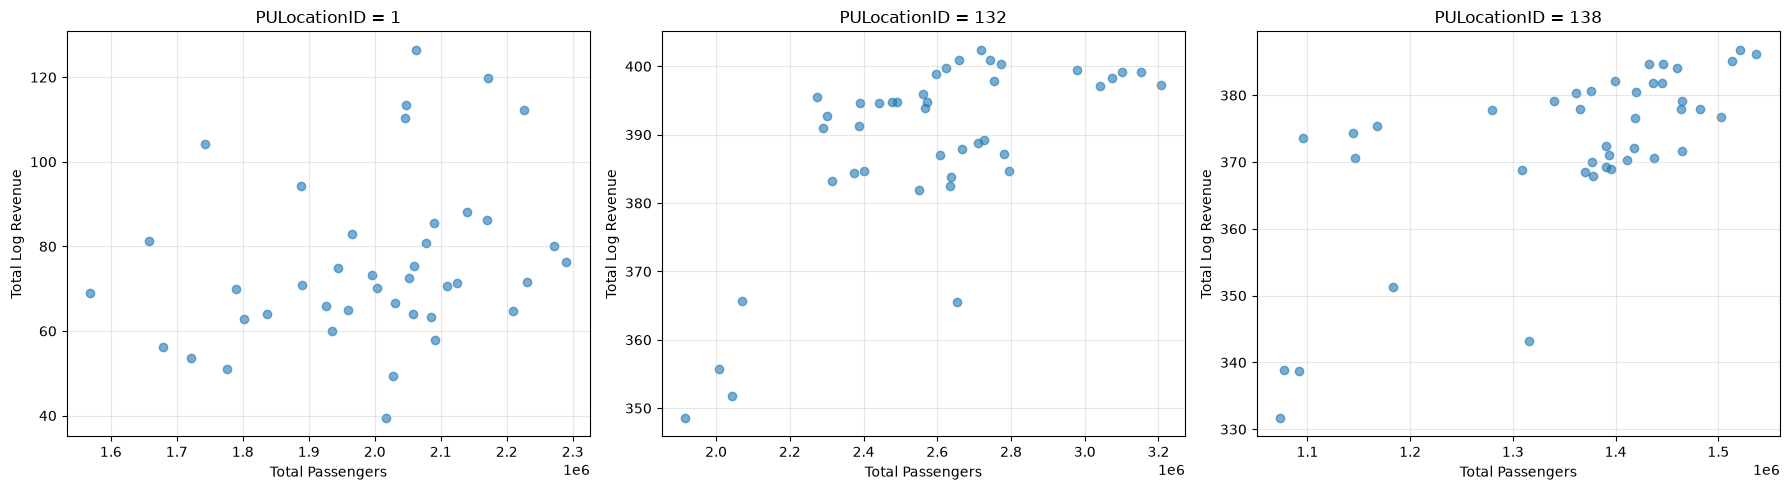

In [157]:
# Get the three PULocationID values
locations = [
    row["PULocationID"]
    for row in combined_with_flights
        .select("PULocationID")
        .distinct()
        .orderBy("PULocationID")
        .collect()
]

# Create a 1x3 collection of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, location in zip(axes, locations):
    # Filter to the current location and collect the plotting data
    data = (
        combined_with_flights
        .filter(combined_with_flights.PULocationID == location)
        .select("total_passengers", "total_log_revenue")
        .dropna()
        .collect()
    )

    x = [row["total_passengers"] for row in data]
    y = [row["total_log_revenue"] for row in data]

    ax.scatter(x, y, alpha=0.6)

    ax.set_title(f"PULocationID = {location}")
    ax.set_xlabel("Total Passengers")
    ax.set_ylabel("Total Log Revenue")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

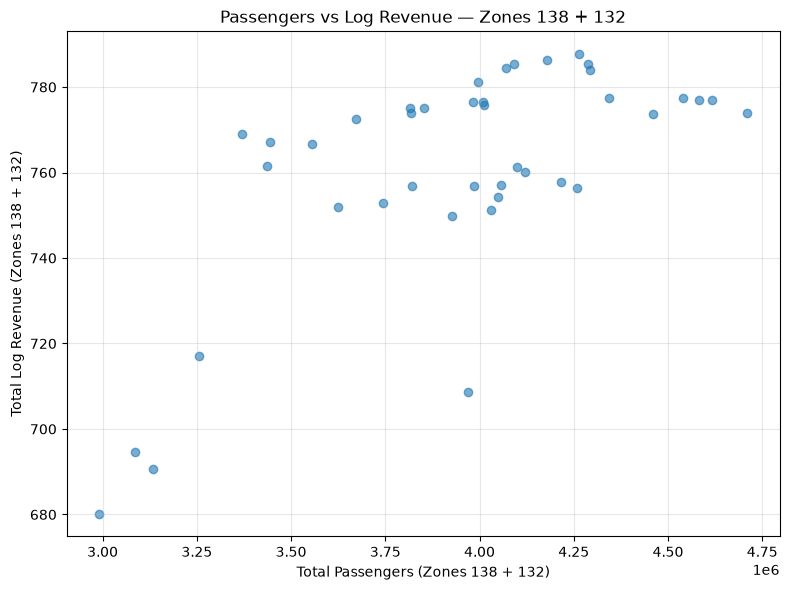

In [159]:
# Filter to zones 138 and 132
# Then group by date and sum across the two zones
daily_sums = (
    combined_with_flights
    .filter(combined_with_flights.PULocationID.isin([138, 132]))
    .groupBy("date")
    .agg(
        {"total_passengers": "sum",
         "total_log_revenue": "sum"}
    )
    .orderBy("date")
)

# Collect for plotting
data = daily_sums.collect()

x = [row["sum(total_passengers)"] for row in data]
y = [row["sum(total_log_revenue)"] for row in data]

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)

plt.xlabel("Total Passengers (Zones 138 + 132)")
plt.ylabel("Total Log Revenue (Zones 138 + 132)")
plt.title("Passengers vs Log Revenue — Zones 138 + 132")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()